<a href="https://colab.research.google.com/github/sn0wsally/self-study-Spatial-Transcriptomics/blob/main/base_study/Breast_Cancer_TME_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install scanpy squidpy leidenalg matplotlib pandas

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of spatialdata to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of spatialdata to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of dask[array,dataframe] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━

In [3]:
import os
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import warnings

In [4]:
warnings.filterwarnings("ignore")

🚀 1. Breast cancer ST data loading... (10x Genomics Visium)


  0%|          | 0.00/9.50M [00:00<?, ?B/s]

  0%|          | 0.00/26.9M [00:00<?, ?B/s]

⚙️ 2. Data Preprocessing & Normalization...
🧮 3. Clustering -> Zonation...
🔬 4. TME & DGE analysis...
🎨 5. Result visualization & Saving ...
Analysis completed ✅ Check '03_breast_cancer_tme_clusters.png' and 'dotplot_tme_markers.png'.


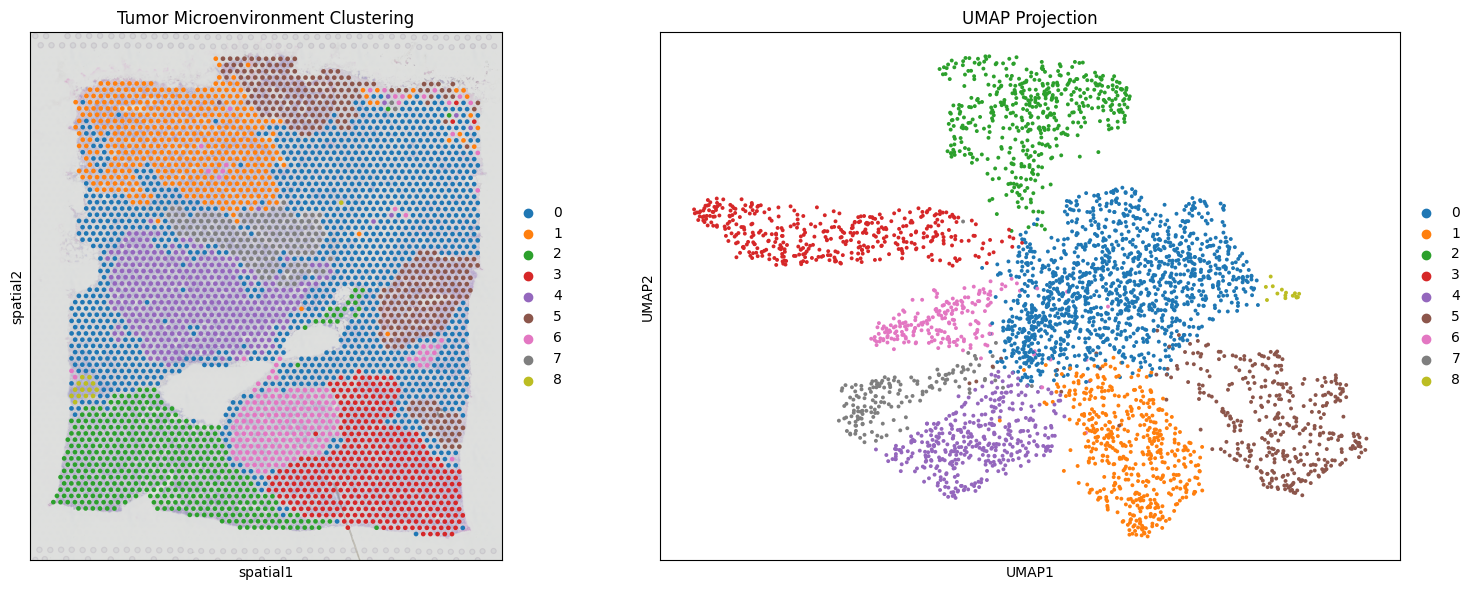

In [5]:
def run_breast_cancer_tme():
    print("🚀 1. Breast cancer ST data loading... (10x Genomics Visium)")
    # Breast Cancer data download (powered by Scanpy built-in function)
    adata = sc.datasets.visium_sge(sample_id="V1_Breast_Cancer_Block_A_Section_1")
    adata.var_names_make_unique()

    # --- Data Preprocessing ---
    print("⚙️ 2. Data Preprocessing & Normalization...")
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
    sc.pp.filter_cells(adata, min_counts=500)
    sc.pp.filter_genes(adata, min_cells=10)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)

    # --- Dimension reduction & Clustering ---
    print("🧮 3. Clustering -> Zonation...")
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

    # clustering only with large blocks (tumor core, immune cell region etc.)
    sc.tl.leiden(adata, resolution=0.5)

    # --- TME (tumor microenvironment) & DGE (distinctive gene expression) analysis ---
    print("🔬 4. TME & DGE analysis...")
    # marker gene extraction by t-test
    sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')

    # --- Visualization ---
    print("🎨 5. Result visualization & Saving ...")
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    # [Figure 1] TME region mapping
    sc.pl.spatial(
        adata,
        color="leiden",
        ax=axs[0],
        title="Tumor Microenvironment Clustering",
        alpha_img=0.5,
        show=False
    )

    # [Figure 2] UMAP
    sc.pl.umap(adata, color="leiden", ax=axs[1], title="UMAP Projection", show=False)
    plt.tight_layout()
    plt.savefig("03_breast_cancer_tme_clusters.png", dpi=300)

    # [Figure 3] Dotplot for Top 5 marker gene expression amount by each cluster
    sc.pl.rank_genes_groups_dotplot(
        adata,
        n_genes=5,
        title="Top 5 Marker Genes per TME Cluster",
        save="_tme_markers.png", # saved as 'dotplot_tme_markers.png'
        show=False
    )

    print("Analysis completed ✅ Check '03_breast_cancer_tme_clusters.png' and 'dotplot_tme_markers.png'.")

if __name__ == "__main__":
    run_breast_cancer_tme()